# Agentic AI Classification & Clustering
**Richard Clay | A23CS0342 | SECP3843-01**

ML notebook: K-Means clustering + Logistic Regression using scikit-learn on Gold parquet.
No PySpark ML (RAM efficient).

### --- Setup & Load Data

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import silhouette_score, classification_report, accuracy_score, confusion_matrix

BASE_DIR = Path(r"C:\Users\richa\individual-project")
GOLD_DIR = BASE_DIR / "05_Output_Gold"
IMG_DIR = BASE_DIR / "docs/report_images"
IMG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(str(GOLD_DIR / 'ai_enriched_agentic_leadership'))
print(f"Loaded {len(df):,} records for ML.")

Loaded 5,500 records for ML.


### --- 1. K-Means Clustering
Segment deployments by performance (Success Rate, Productivity, Trust).

In [2]:
features_km = ['Task_Success_Rate', 'Productivity_Improvement_Percent', 'Leadership_Trust_Score']
X_km = df[features_km].copy()
scaler_km = StandardScaler()
X_km_scaled = scaler_km.fit_transform(X_km)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_km_scaled)

prod_centroids = kmeans.cluster_centers_[:, 1]
sorted_idx = np.argsort(prod_centroids)
label_map = {sorted_idx[0]: 'Low', sorted_idx[1]: 'Avg', sorted_idx[2]: 'High'}
df['AI_Performance_Label'] = df['Cluster'].map(label_map)

sil = silhouette_score(X_km_scaled, df['Cluster'], sample_size=1000)
print(f"Silhouette Score: {sil:.4f}")
print(df['AI_Performance_Label'].value_counts())

Silhouette Score: 0.3344
AI_Performance_Label
High    2362
Low     1824
Avg     1314
Name: count, dtype: int64


### --- 2. Logistic Regression
Predict Productivity_Category from system telemetry.

In [3]:
le_c = LabelEncoder()
df['Complexity_Enc'] = le_c.fit_transform(df['Task_Complexity_Level'])
le_a = LabelEncoder()
df['Adoption_Enc'] = le_a.fit_transform(df['Adoption_Success_Level'])

lr_features = ['Context_Awareness_Score', 'Response_Time_Seconds', 'Complexity_Enc', 'Adoption_Enc', 'Error_Count']
X_lr = df[lr_features]
y_lr = df['Productivity_Category']

X_tr, X_te, y_tr, y_te = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr)
scaler_lr = StandardScaler()
X_tr_s = scaler_lr.fit_transform(X_tr)
X_te_s = scaler_lr.transform(X_te)

grid = GridSearchCV(LogisticRegression(max_iter=500, random_state=42), param_grid={'C': [1, 10, 50]}, cv=3)
grid.fit(X_tr_s, y_tr)
best = grid.best_estimator_
y_pred = best.predict(X_te_s)

print(f"C: {grid.best_params_['C']} | Acc: {accuracy_score(y_te, y_pred):.4f}")
print(classification_report(y_te, y_pred))

C: 1 | Acc: 0.6209
              precision    recall  f1-score   support

        High       0.64      0.61      0.62       220
         Low       0.61      0.61      0.61       364
      Medium       0.62      0.63      0.62       516

    accuracy                           0.62      1100
   macro avg       0.62      0.62      0.62      1100
weighted avg       0.62      0.62      0.62      1100



### --- 3. Cluster Distribution

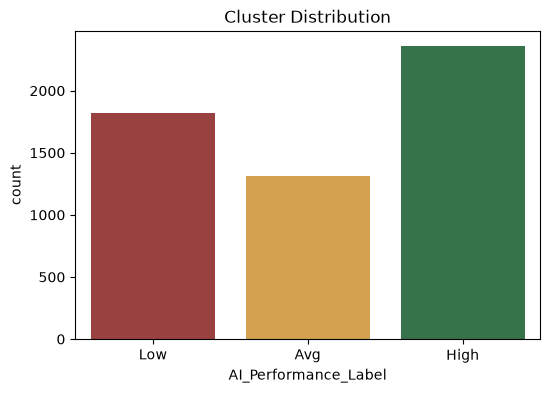

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='AI_Performance_Label', palette={'High':'#2d7d46','Avg':'#e8a838','Low':'#a83232'})
plt.title('Cluster Distribution')
plt.savefig(str(IMG_DIR / 'cluster_analysis.png'), dpi=150)
plt.show()

### --- 4. Confusion Matrix

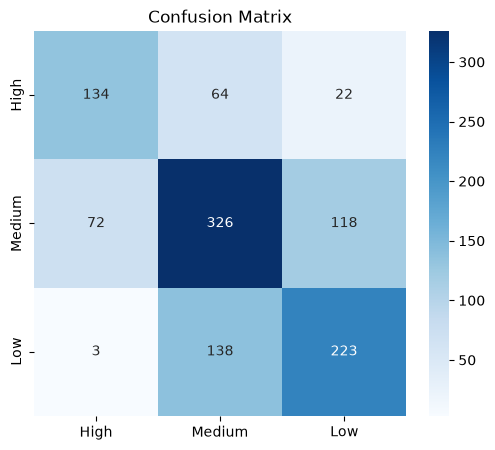

In [5]:
cm = confusion_matrix(y_te, y_pred, labels=['High','Medium','Low'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['High','Medium','Low'], yticklabels=['High','Medium','Low'])
plt.title('Confusion Matrix')
plt.savefig(str(IMG_DIR / 'confusion_matrix.png'), dpi=150)
plt.show()

### --- 5. Feature Importance

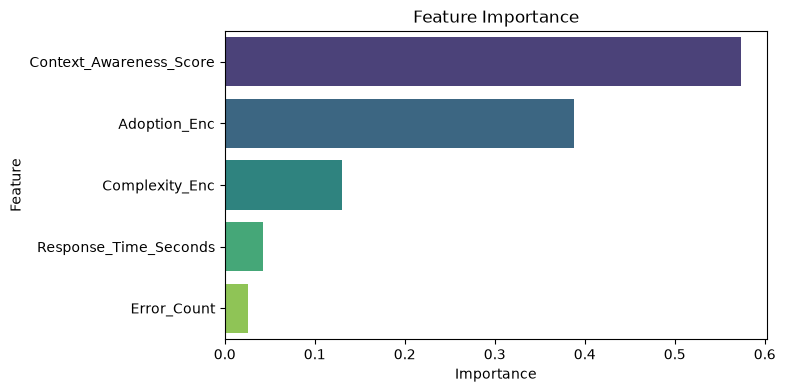

In [6]:
imp = np.mean(np.abs(best.coef_), axis=0)
imp_df = pd.DataFrame({'Feature':lr_features,'Importance':imp}).sort_values('Importance',ascending=False)
plt.figure(figsize=(7,4))
sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance')
plt.savefig(str(IMG_DIR / 'lr_feature_importance.png'), dpi=150)
plt.show()

### --- 6. Trust Gap by Industry

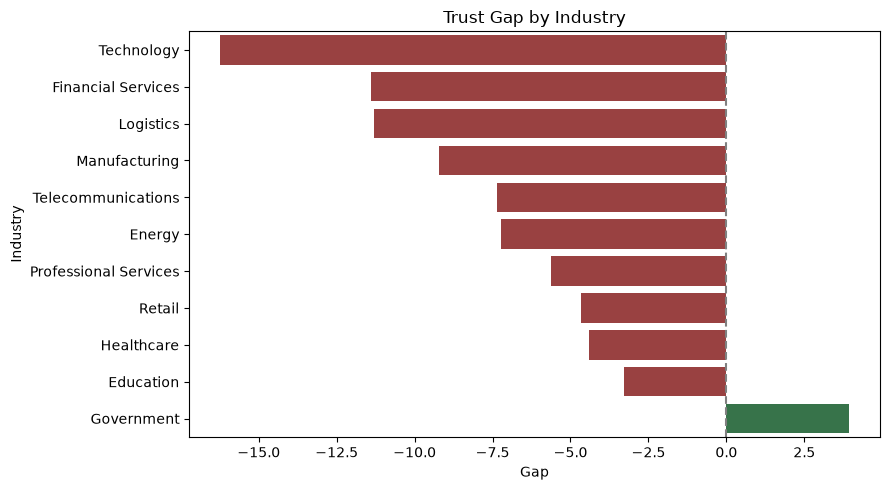

In [7]:
gaps = df.groupby('Industry').agg({'Leadership_Trust_Score':'mean','Benchmark_Trust_Score':'mean'}).reset_index()
gaps['Gap'] = gaps['Leadership_Trust_Score'] - gaps['Benchmark_Trust_Score']
gaps = gaps.sort_values('Gap')
colors = ['#a83232' if x<0 else '#2d7d46' for x in gaps['Gap']]
plt.figure(figsize=(9,5))
sns.barplot(data=gaps, x='Gap', y='Industry', palette=colors)
plt.axvline(0, color='gray', ls='--')
plt.title('Trust Gap by Industry')
plt.tight_layout()
plt.savefig(str(IMG_DIR / 'trust_gap_by_industry.png'), dpi=150)
plt.show()